In [ ]:
!pip install -q statsbombpy mplsoccer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch


# **DATA EXTRACTION**

In [ ]:
from statsbombpy import sb
import pandas as pd

# Euro 2024 -> competition_id = 55, season_id = 282
comp_id, season_id = 55, 282

# 1. Obtener lista de partidos
matches = sb.matches(competition_id=comp_id, season_id=season_id)
print("Total matches:", len(matches))

# 2. Descargar EVENTS de todos los partidos
events_list, lineups_list, frames_list = [], [], []

for mid in matches['match_id'].unique():
    try:
        # --- Events ---
        ev = sb.events(match_id=mid)
        ev['match_id'] = mid
        events_list.append(ev)

        # --- Lineups ---
        lu = sb.lineups(match_id=mid)
        for team, df in lu.items():
            df['match_id'] = mid
            df['team'] = team
            lineups_list.append(df)

        # --- Frames360 ---
        fr = sb.frames(match_id=mid)
        fr['match_id'] = mid
        frames_list.append(fr)

        print(f"OK -> match {mid}: events {len(ev)}, lineups {len(lu)}, frames {len(fr)}")

    except Exception as e:
        print(f"Error en match {mid}: {e}")

# 3. Concatenar todo
events = pd.concat(events_list, ignore_index=True)
lineups = pd.concat(lineups_list, ignore_index=True)
frames360 = pd.concat(frames_list, ignore_index=True)

print("Events shape:", events.shape)
print("Lineups shape:", lineups.shape)
print("Frames360 shape:", frames360.shape)



Total matches: 51
OK -> match 3942819: events 3485, lineups 2, frames 51397
OK -> match 3943043: events 3312, lineups 2, frames 46970
OK -> match 3942752: events 3328, lineups 2, frames 39929
OK -> match 3942382: events 3415, lineups 2, frames 48518
OK -> match 3942349: events 5190, lineups 2, frames 74904
OK -> match 3930180: events 3198, lineups 2, frames 45890
OK -> match 3930171: events 3881, lineups 2, frames 57820
OK -> match 3942227: events 4882, lineups 2, frames 74093
OK -> match 3942226: events 4463, lineups 2, frames 58053
OK -> match 3938645: events 3525, lineups 2, frames 45328
OK -> match 3930184: events 2953, lineups 2, frames 39115
OK -> match 3941022: events 3722, lineups 2, frames 51890
OK -> match 3941021: events 2996, lineups 2, frames 34551
OK -> match 3941020: events 4221, lineups 2, frames 62130
OK -> match 3941019: events 3941, lineups 2, frames 55645
OK -> match 3941018: events 3949, lineups 2, frames 63942
OK -> match 3941017: events 4764, lineups 2, frames 69

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [ ]:

import pandas as pd
import numpy as np
from statsbombpy import sb

# ---------- Step 0. Helpers ----------
def pick_col(df, *cands):
    """Return the first column name that exists in df among candidates."""
    for c in cands:
        if c in df.columns:
            return c
    return None

def per90(x, minutes):
    """Per-90 computation that avoids division by zero."""
    return x / (minutes / 90.0)

def add_count(df, key_col, label):
    """Group-by count by player key (robust to empty)."""
    if df is None or df.empty:
        return pd.DataFrame({'pkey':[], label:[]})
    out = df[[key_col]].dropna().groupby(key_col).size().rename(label).reset_index()
    return out.rename(columns={key_col:'pkey'})

def add_sum(df, key_col, value_col, label):
    """Group-by sum by player key (robust to empty/missing column)."""
    if df is None or df.empty or value_col not in df.columns:
        return pd.DataFrame({'pkey':[], label:[]})
    out = (df[[key_col, value_col]]
           .dropna(subset=[key_col])
           .groupby(key_col)[value_col]
           .sum()
           .rename(label)
           .reset_index())
    return out.rename(columns={key_col:'pkey'})


# ---------- Step 2. Standardize core columns ----------
# Tip: SB sometimes uses nested names (e.g., 'type.name'). pick_col handles both.
col_type   = pick_col(events, 'type', 'type.name')
col_team   = pick_col(events, 'team', 'team.name')
col_pname  = pick_col(events, 'player', 'player.name')
col_pid    = pick_col(events, 'player_id', 'player.id')
col_pkey   = col_pid or col_pname      # robust player identifier
col_pos    = pick_col(events, 'position', 'position.name')
assert col_type and col_pkey and col_team and col_pname, "Missing essential columns."

# ---------- Step 3. Minutes & matches (simple) ----------
# Minutes-per-match = max(minute) + 1 (cap not applied here; matches can have ET)
m_pm = (events.dropna(subset=[col_pkey, 'minute'])
              .groupby(['match_id', col_pkey], as_index=False)['minute']
              .max())
m_pm['minutes_pm'] = m_pm['minute'].astype(float) + 1.0

mins_total = (m_pm.groupby(col_pkey, as_index=False)['minutes_pm']
                .sum()
                .rename(columns={col_pkey:'pkey', 'minutes_pm':'minutes'}))

games_total = (m_pm.groupby(col_pkey, as_index=False)['match_id']
                 .nunique()
                 .rename(columns={col_pkey:'pkey', 'match_id':'matches'}))

# Primary team & position (mode across events)
team_map = (events[[col_pkey, col_team]].dropna()
            .groupby(col_pkey)[col_team]
            .agg(lambda s: s.value_counts().index[0])
            .reset_index()
            .rename(columns={col_pkey:'pkey', col_team:'team_name'}))

pos_series = events[col_pos]
if pos_series is not None and pos_series.apply(lambda v: isinstance(v, dict)).any():
    pos_series = pos_series.apply(lambda d: d.get('name') if isinstance(d, dict) else d)

pos_map = (pd.concat([events[col_pkey], pos_series], axis=1)
           .dropna()
           .groupby(col_pkey)[pos_series.name]
           .agg(lambda s: s.value_counts().index[0])
           .reset_index()
           .rename(columns={col_pkey:'pkey', pos_series.name:'position_name'}))

# Build base table
tot = (mins_total.merge(games_total, on='pkey', how='left')
                 .merge(team_map,   on='pkey', how='left')
                 .merge(pos_map,    on='pkey', how='left'))

# Add display name
name_map = (events[[col_pkey, col_pname]]
            .dropna()
            .drop_duplicates()
            .rename(columns={col_pkey:'pkey', col_pname:'player_name'}))
tot = tot.merge(name_map, on='pkey', how='left')

# ---------- Step 4. Subsets ----------
shots      = events[events[col_type].eq('Shot')].copy()
passes     = events[events[col_type].eq('Pass')].copy()
dribbles   = events[events[col_type].eq('Dribble')].copy()
pressures  = events[events[col_type].eq('Pressure')].copy()
tackles    = events[events[col_type].eq('Tackle')].copy()
intercepts = events[events[col_type].eq('Interception')].copy()
blocks     = events[events[col_type].eq('Block')].copy()
clearances = events[events[col_type].eq('Clearance')].copy()
carries    = events[events[col_type].eq('Carry')].copy()
foul_won   = events[events[col_type].eq('Foul Won')].copy()
foul_comm  = events[events[col_type].eq('Foul Committed')].copy()
ball_recv  = events[events[col_type].eq('Ball Receipt')].copy()
recoveries = events[events[col_type].eq('Recovery')].copy()
duels      = events[events[col_type].eq('Duel')].copy()

# Useful nested columns
col_sh_out   = pick_col(events, 'shot_outcome', 'shot.outcome', 'shot.outcome.name')
col_xg       = pick_col(events, 'shot_statsbomb_xg', 'shot.statsbomb_xg')
col_pass_out = pick_col(events, 'pass_outcome', 'pass.outcome', 'pass.outcome.name')
col_pass_len = pick_col(events, 'pass_length', 'pass.length')
col_pass_end = pick_col(events, 'pass_end_location', 'pass.end_location')
col_loc      = 'location'  # standard SB field for start location

# ---------- Step 5. Offensive production ----------
# Goals & shots on target
goals = shots[shots[col_sh_out].astype(str).str.lower().eq('goal')] if (col_sh_out in shots.columns) else shots.iloc[0:0]
sot   = shots[shots[col_sh_out].astype(str).str.lower().isin(['saved', 'goal'])] if (col_sh_out in shots.columns) else shots.iloc[0:0]

# Key passes & assists
col_kp_id = pick_col(shots, 'shot_key_pass_id', 'shot.key_pass_id')
if col_kp_id and col_kp_id in shots.columns and 'id' in passes.columns:
    key_pass_ids = set(shots[col_kp_id].dropna().tolist())
    kp_passes = passes[passes['id'].isin(key_pass_ids)]
    goal_kp_ids = set(shots.loc[shots[col_sh_out].astype(str).str.lower().eq('goal'), col_kp_id].dropna().tolist()) if (col_sh_out in shots.columns) else set()
    ast_passes = passes[passes['id'].isin(goal_kp_ids)]
else:
    kp_passes = passes.iloc[0:0]
    ast_passes = passes.iloc[0:0]

# Expected Assists (sum xG of shots assisted by the player's passes)
if col_kp_id and (col_kp_id in shots.columns) and col_xg and (col_xg in shots.columns) and ('id' in passes.columns):
    xA_by_pass = (shots.dropna(subset=[col_kp_id, col_xg])
                       .groupby(col_kp_id)[col_xg]
                       .sum()
                       .rename('xA_from_pass')
                       .reset_index())
    xA_pass = passes[['id', col_pkey]].merge(xA_by_pass, left_on='id', right_on=col_kp_id, how='inner')
    xA = xA_pass.groupby(col_pkey)['xA_from_pass'].sum().rename('xA').reset_index().rename(columns={col_pkey:'pkey'})
else:
    xA = pd.DataFrame({'pkey':[], 'xA':[]})

# Merge production
for label, df in [('Gls', goals), ('Sh', shots), ('SoT', sot), ('KP', kp_passes), ('Ast', ast_passes)]:
    tot = tot.merge(add_count(df, col_pkey, label), on='pkey', how='left')

# xG & xA
if col_xg and col_xg in shots.columns:
    tot = tot.merge(add_sum(shots, col_pkey, col_xg, 'xG'), on='pkey', how='left')
else:
    tot['xG'] = 0.0
tot = tot.merge(xA, on='pkey', how='left')
tot['xA'] = tot['xA'].fillna(0.0)

# Rates
tot['SoT%'] = np.where(tot['Sh']>0, tot['SoT']/tot['Sh'], 0.0)
tot['G/Sh'] = np.where(tot['Sh']>0, tot['Gls']/tot['Sh'], 0.0)
tot['G-xG'] = tot['Gls'] - tot['xG']

# ---------- Step 6. Passing: attempts, completions, length buckets, under pressure, progressive ----------
# Completed passes (in SB open data, NaN outcome ≈ completed)
passes_comp = passes[passes[col_pass_out].isna()] if (col_pass_out and col_pass_out in passes.columns) else passes.iloc[0:0]

# Length buckets (Short <15m, Medium 15–30m, Long >30m)
if col_pass_len and col_pass_len in passes.columns:
    p_len = passes[[col_pkey, col_pass_len, col_pass_out]].copy()
    p_len['L'] = p_len[col_pass_len].astype(float)

    short_att = p_len[p_len['L'] < 15]
    med_att   = p_len[(p_len['L'] >= 15) & (p_len['L'] < 30)]
    long_att  = p_len[p_len['L'] >= 30]

    # completions by length (outcome NaN)
    if col_pass_out in p_len.columns:
        short_cmp = short_att[short_att[col_pass_out].isna()]
        med_cmp   = med_att[med_att[col_pass_out].isna()]
        long_cmp  = long_att[long_att[col_pass_out].isna()]
    else:
        short_cmp = short_att.iloc[0:0]; med_cmp = med_att.iloc[0:0]; long_cmp = long_att.iloc[0:0]
else:
    short_att = med_att = long_att = passes.iloc[0:0]
    short_cmp = med_cmp = long_cmp = passes.iloc[0:0]

# Under pressure (event flag, no 360)
passes_up = passes[passes['under_pressure'] == True] if 'under_pressure' in passes.columns else passes.iloc[0:0]

# Progressive passes:
if 'pass_progressive' in passes.columns:
    passes_prog = passes[passes['pass_progressive'] == True]
elif (col_pass_end in passes.columns) and (col_loc in passes.columns):
    tmp_pp = passes[[col_pkey, col_loc, col_pass_end]].dropna().copy()
    def is_prog(row):
        try:
            sx = float(row[col_loc][0]); ex = float(row[col_pass_end][0])
            return (ex - sx) > 10 and ex > 40
        except:
            return False
    tmp_pp['prog'] = tmp_pp.apply(is_prog, axis=1)
    passes_prog = tmp_pp[tmp_pp['prog']]
else:
    passes_prog = passes.iloc[0:0]

# Merge passing metrics
tot = (tot
       .merge(add_count(passes,      col_pkey, 'Passes_Att'), on='pkey', how='left')
       .merge(add_count(passes_comp, col_pkey, 'Passes_Cmp'), on='pkey', how='left')
       # length buckets (attempts + completions)
       .merge(add_count(short_att,   col_pkey, 'Pass_Short_Att'), on='pkey', how='left')
       .merge(add_count(short_cmp,   col_pkey, 'Pass_Short_Cmp'), on='pkey', how='left')
       .merge(add_count(med_att,     col_pkey, 'Pass_Medium_Att'), on='pkey', how='left')
       .merge(add_count(med_cmp,     col_pkey, 'Pass_Medium_Cmp'), on='pkey', how='left')
       .merge(add_count(long_att,    col_pkey, 'Pass_Long_Att'), on='pkey', how='left')
       .merge(add_count(long_cmp,    col_pkey, 'Pass_Long_Cmp'), on='pkey', how='left')
       # pressure & progressive
       .merge(add_count(passes_up,   col_pkey, 'Passes_UnderPress'), on='pkey', how='left')
       .merge(add_count(passes_prog, col_pkey, 'Pass_Prog'), on='pkey', how='left')
      )

# Accuracy & shares
for att, cmp_, pct in [
    ('Passes_Att','Passes_Cmp','Passes_Cmp%'),
    ('Pass_Short_Att','Pass_Short_Cmp','Pass_Short_Cmp%'),
    ('Pass_Medium_Att','Pass_Medium_Cmp','Pass_Medium_Cmp%'),
    ('Pass_Long_Att','Pass_Long_Cmp','Pass_Long_Cmp%'),
]:
    tot[[att,cmp_]] = tot[[att,cmp_]].fillna(0)
    tot[pct] = np.where(tot[att] > 0, tot[cmp_] / tot[att], 0.0)

# Distribution of attempts by length
tot['Pass_Short%']  = np.where(tot['Passes_Att']>0, tot['Pass_Short_Att']/tot['Passes_Att'], 0.0)
tot['Pass_Medium%'] = np.where(tot['Passes_Att']>0, tot['Pass_Medium_Att']/tot['Passes_Att'], 0.0)
tot['Pass_Long%']   = np.where(tot['Passes_Att']>0, tot['Pass_Long_Att']/tot['Passes_Att'], 0.0)

# Pressure share on passes
tot['Passes_UnderPress%'] = np.where(tot['Passes_Att']>0, tot['Passes_UnderPress']/tot['Passes_Att'], 0.0)

# ---------- Step 6b. Line-breaking passes (LBP) ----------

# 1. Compute defensive barrier per event (max opponent x-position in freeze frame)
opp = frames360[(frames360['teammate'] == False) & frames360['location'].notna()].copy()
bars = (opp.groupby('id')['location']
          .apply(lambda loc: np.max([float(v[0]) for v in loc]))
          .rename('bar_x')
          .reset_index()
          .rename(columns={'id':'event_id'}))

# 2. Completed passes only (NaN outcome = completed in open data)
passes_comp = passes[passes[col_pass_out].isna()].dropna(subset=[col_loc, col_pass_end]).copy()

pc = passes_comp[[col_pkey, col_loc, col_pass_end, 'id']].rename(columns={'id':'event_id'})
pc = pc.merge(bars, on='event_id', how='left')

# 3. Detect LBP (start_x <= bar_x < end_x, with forward movement > 2m)
pc['sx'] = pc[col_loc].apply(lambda v: float(v[0]))
pc['ex'] = pc[col_pass_end].apply(lambda v: float(v[0]))

lbp_mask = (pc['ex'] - pc['sx'] > 2.0) & (pc['sx'] <= pc['bar_x']) & (pc['ex'] > pc['bar_x'])
lbp_counts = (pc[lbp_mask]
              .groupby(col_pkey)
              .size()
              .reset_index(name='Pass_LBP')
              .rename(columns={col_pkey: 'pkey'}))

# 4. Merge into final table
tot = tot.merge(lbp_counts, on='pkey', how='left')
tot['Pass_LBP'] = tot['Pass_LBP'].fillna(0).astype(int)


# ---------- Step 7. Carries, progressive carries, recoveries, defensive, fouls, touches ----------
# Progressive carries:
# Prefer native 'carry_progressive' if present; else heuristic: dx > 5 and end_x > 40
if 'carry_progressive' in carries.columns:
    carries_prog = carries[carries['carry_progressive'] == True]
elif (col_loc in carries.columns) and ('carry_end_location' in carries.columns):
    c_tmp = carries[[col_pkey, col_loc, 'carry_end_location']].dropna().copy()
    def c_dx(row):
        try:
            return float(row['carry_end_location'][0]) - float(row[col_loc][0])
        except:
            return np.nan
    c_tmp['dx'] = c_tmp.apply(c_dx, axis=1)
    carries_prog = c_tmp[(c_tmp['dx'] > 5) & (c_tmp['carry_end_location'].apply(lambda v: isinstance(v,(list,tuple)) and float(v[0]) > 40))]
else:
    carries_prog = carries.iloc[0:0]

# Aerials (if present in Duel subtype)
duel_type_col = pick_col(duels, 'duel_type', 'duel.type', 'duel.type.name')
duel_out_col  = pick_col(duels, 'duel_outcome', 'duel.outcome', 'duel.outcome.name')
if duel_type_col and duel_out_col and (duel_type_col in duels.columns) and (duel_out_col in duels.columns):
    aerials = duels[duels[duel_type_col].astype(str).str.contains('Aerial', case=False, na=False)]
    aer_won = aerials[aerials[duel_out_col].astype(str).str.contains('Won', case=False, na=False)]
else:
    aerials = duels.iloc[0:0]; aer_won = duels.iloc[0:0]

# Cards from Foul Committed (if card field exists)
card_col = pick_col(foul_comm, 'foul_committed_card', 'foul_committed.card', 'foul_committed_card.name', 'foul_committed.card.name')
if card_col and card_col in foul_comm.columns:
    yellow = foul_comm[foul_comm[card_col].astype(str).str.contains('Yellow', case=False, na=False)]
    red    = foul_comm[foul_comm[card_col].astype(str).str.contains('Red', case=False, na=False)]
else:
    yellow = foul_comm.iloc[0:0]; red = foul_comm.iloc[0:0]

# Touches in final third / box (simple geometric proxy on SB pitch 120x80)
def in_box(loc):
    try:
        x, y = float(loc[0]), float(loc[1])
        return (x >= 102) and (18 <= y <= 62)
    except:
        return False

def in_att_third(loc):
    try:
        return float(loc[0]) >= 80
    except:
        return False

onball = events[[col_pkey, col_loc]].dropna().copy()
onball['att3rd'] = onball[col_loc].apply(in_att_third)
onball['box']    = onball[col_loc].apply(in_box)
touch_att3rd = onball[onball['att3rd']]
touch_box    = onball[onball['box']]

# Merge counts
for label, df in [
    ('Carries', carries),
    ('Carries_Prog', carries_prog),
    ('Recoveries', recoveries),
    ('Press', pressures),
    ('Tackles', tackles),
    ('Int', intercepts),
    ('Blocks', blocks),
    ('Clr', clearances),
    ('Fouls_Won', foul_won),
    ('Fouls_Committed', foul_comm),
    ('Aerials_Att', aerials),
    ('Aer_Won', aer_won),
    ('Touches_Att3rd', touch_att3rd),
    ('Touches_Box', touch_box),
]:
    tot = tot.merge(add_count(df, col_pkey, label), on='pkey', how='left')

# Aerial win rate
tot[['Aerials_Att','Aer_Won']] = tot[['Aerials_Att','Aer_Won']].fillna(0)
tot['Aer_Win%'] = np.where(tot['Aerials_Att']>0, tot['Aer_Won']/tot['Aerials_Att'], 0.0)

# Cards
tot = (tot.merge(add_count(yellow, col_pkey, 'Yellow'), on='pkey', how='left')
          .merge(add_count(red,    col_pkey, 'Red'),    on='pkey', how='left'))

# ---------- Step 8. Per-90 + tidy ----------
count_cols = ['matches','minutes','Gls','Sh','SoT','KP','Ast','xG','xA',
              'Passes_Att','Passes_Cmp','Pass_Short_Att','Pass_Short_Cmp','Pass_Medium_Att','Pass_Medium_Cmp','Pass_Long_Att','Pass_Long_Cmp',
              'Passes_UnderPress', "Pass_LBP",'Pass_Prog',
              'Carries','Carries_Prog','Recoveries','Press','Tackles','Int','Blocks','Clr',
              'Fouls_Won','Fouls_Committed','Aerials_Att','Aer_Won','Touches_Att3rd','Touches_Box','Yellow','Red']
for c in count_cols:
    if c not in tot.columns:
        tot[c] = 0
tot[count_cols] = tot[count_cols].fillna(0)

per90_cols = ['Gls','Sh','SoT','KP','Ast','xG','xA',
              'Passes_Att','Passes_Cmp',
              'Pass_Short_Att','Pass_Short_Cmp','Pass_Medium_Att','Pass_Medium_Cmp','Pass_Long_Att','Pass_Long_Cmp',
              'Passes_UnderPress','Pass_Prog', "Pass_LBP",
              'Carries','Carries_Prog','Recoveries','Press','Tackles','Int','Blocks','Clr',
              'Fouls_Won','Fouls_Committed','Aerials_Att','Aer_Won','Touches_Att3rd','Touches_Box']
for c in per90_cols:
    tot[c+'_90'] = per90(tot[c].astype(float), tot['minutes'].replace(0, np.nan))

# Final extra rates
tot['Passes_Cmp%']        = np.where(tot['Passes_Att']>0, tot['Passes_Cmp']/tot['Passes_Att'], 0.0)
tot['Pass_Short_Cmp%']    = np.where(tot['Pass_Short_Att']>0, tot['Pass_Short_Cmp']/tot['Pass_Short_Att'], 0.0)
tot['Pass_Medium_Cmp%']   = np.where(tot['Pass_Medium_Att']>0, tot['Pass_Medium_Cmp']/tot['Pass_Medium_Att'], 0.0)
tot['Pass_Long_Cmp%']     = np.where(tot['Pass_Long_Att']>0, tot['Pass_Long_Cmp']/tot['Pass_Long_Att'], 0.0)
tot['Passes_UnderPress%'] = np.where(tot['Passes_Att']>0, tot['Passes_UnderPress']/tot['Passes_Att'], 0.0)
tot['SoT%']               = np.where(tot['Sh']>0, tot['SoT']/tot['Sh'], 0.0)
tot['G/Sh']               = np.where(tot['Sh']>0, tot['Gls']/tot['Sh'], 0.0)
tot['G-xG']               = tot['Gls'] - tot['xG']
tot['Aer_Win%']           = np.where(tot['Aerials_Att']>0, tot['Aer_Won']/tot['Aerials_Att'], 0.0)

# ---------- Step 9. Column order & preview ----------
cols = [
    'player_name','team_name','position_name','matches','minutes',
    'Gls','Sh','SoT','SoT%','KP','Ast','xG','xA','G/Sh','G-xG',
    'Passes_Att','Passes_Cmp','Passes_Cmp%',
    'Pass_Short_Att','Pass_Short_Cmp','Pass_Short_Cmp%','Pass_Short%','Pass_Short_Att_90','Pass_Short_Cmp_90',
    'Pass_Medium_Att','Pass_Medium_Cmp','Pass_Medium_Cmp%','Pass_Medium%','Pass_Medium_Att_90','Pass_Medium_Cmp_90',
    'Pass_Long_Att','Pass_Long_Cmp','Pass_Long_Cmp%','Pass_Long%','Pass_Long_Att_90','Pass_Long_Cmp_90',
    'Passes_UnderPress','Passes_UnderPress%','Passes_UnderPress_90',
    'Pass_Prog','Pass_Prog_90', "Pass_LBP", "Pass_LBP_90",
    'Carries','Carries_Prog','Carries_90','Carries_Prog_90',
    'Recoveries','Recoveries_90',
    'Press','Tackles','Int','Blocks','Clr','Press_90','Tackles_90','Int_90','Blocks_90','Clr_90',
    'Fouls_Won','Fouls_Committed','Fouls_Won_90','Fouls_Committed_90',
    'Aerials_Att','Aer_Won','Aer_Win%','Aerials_Att_90','Aer_Won_90',
    'Touches_Att3rd','Touches_Box','Touches_Att3rd_90','Touches_Box_90',
    'Yellow','Red'
]
tot = tot[[c for c in cols if c in tot.columns]].sort_values(['team_name','player_name']).reset_index(drop=True)
display(tot.head(20))




,player_name,team_name,position_name,matches,minutes,Gls,Sh,SoT,SoT%,KP,Ast,xG,xA,G/Sh,G-xG,Passes_Att,Passes_Cmp,Passes_Cmp%,Pass_Short_Att,Pass_Short_Cmp,Pass_Short_Cmp%,Pass_Short%,Pass_Short_Att_90,Pass_Short_Cmp_90,Pass_Medium_Att,Pass_Medium_Cmp,Pass_Medium_Cmp%,Pass_Medium%,Pass_Medium_Att_90,Pass_Medium_Cmp_90,Pass_Long_Att,Pass_Long_Cmp,Pass_Long_Cmp%,Pass_Long%,Pass_Long_Att_90,Pass_Long_Cmp_90,Passes_UnderPress,Passes_UnderPress%,Passes_UnderPress_90,Pass_Prog,Pass_Prog_90,Pass_LBP,Pass_LBP_90,Carries,Carries_Prog,Carries_90,Carries_Prog_90,Recoveries,Recoveries_90,Press,Tackles,Int,Blocks,Clr,Press_90,Tackles_90,Int_90,Blocks_90,Clr_90,Fouls_Won,Fouls_Committed,Fouls_Won_90,Fouls_Committed_90,Aerials_Att,Aer_Won,Aer_Win%,Aerials_Att_90,Aer_Won_90,Touches_Att3rd,Touches_Box,Touches_Att3rd_90,Touches_Box_90,Yellow,Red
0,Arbër Hoxha,Albania,Left Wing,3,286.0,0.0,2.0,1.0,0.500000,1.0,0.0,0.092657,0.030681,0.000000,-0.092657,20.0,15.0,0.750000,15.0,11.0,0.733333,0.750000,4.720280,3.461538,5.0,4.0,0.800000,0.250000,1.573427,1.258741,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5.0,0.250000,1.573427,2.0,0.629371,1,0.314685,27.0,12.0,8.496503,3.776224,0.0,0.0,17.0,0.0,0.0,1.0,0.0,5.349650,0.0,0.000000,0.314685,0.000000,3.0,1.0,0.944056,0.314685,1.0,0.0,0.0,0.314685,0.0,48.0,6.0,15.104895,1.888112,1.0,0.0
1,Arlind Afrim Ajeti,Albania,Right Center Back,3,286.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,107.0,90.0,0.841121,37.0,33.0,0.891892,0.345794,11.643357,10.384615,43.0,39.0,0.906977,0.401869,13.531469,12.272727,27.0,18.0,0.666667,0.252336,8.496503,5.664336,13.0,0.121495,4.090909,32.0,10.069930,2,0.629371,78.0,6.0,24.545455,1.888112,0.0,0.0,16.0,0.0,7.0,6.0,11.0,5.034965,0.0,2.202797,1.888112,3.461538,0.0,1.0,0.000000,0.314685,7.0,0.0,0.0,2.202797,0.0,5.0,1.0,1.573427,0.314685,0.0,0.0
2,Armando Broja,Albania,Center Forward,2,170.0,0.0,2.0,2.0,1.000000,2.0,0.0,0.228905,0.040735,0.000000,-0.228905,17.0,11.0,0.647059,12.0,7.0,0.583333,0.705882,6.352941,3.705882,5.0,4.0,0.800000,0.294118,2.647059,2.117647,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5.0,0.294118,2.647059,5.0,2.647059,2,1.058824,24.0,7.0,12.705882,3.705882,0.0,0.0,11.0,0.0,1.0,1.0,1.0,5.823529,0.0,0.529412,0.529412,0.529412,6.0,2.0,3.176471,1.058824,4.0,0.0,0.0,2.117647,0.0,40.0,9.0,21.176471,4.764706,0.0,0.0
3,Berat Djimsiti,Albania,Left Center Back,3,286.0,0.0,2.0,0.0,0.000000,1.0,0.0,0.104327,0.023187,0.000000,-0.104327,143.0,129.0,0.902098,61.0,56.0,0.918033,0.426573,19.195804,17.622378,66.0,62.0,0.939394,0.461538,20.769231,19.510490,16.0,11.0,0.687500,0.111888,5.034965,3.461538,12.0,0.083916,3.776224,44.0,13.846154,4,1.258741,101.0,8.0,31.783217,2.517483,0.0,0.0,19.0,0.0,2.0,10.0,16.0,5.979021,0.0,0.629371,3.146853,5.034965,2.0,1.0,0.629371,0.314685,4.0,0.0,0.0,1.258741,0.0,13.0,6.0,4.090909,1.888112,0.0,0.0
4,Elseid Hysaj,Albania,Right Back,2,191.0,0.0,2.0,0.0,0.000000,1.0,0.0,0.097810,0.042952,0.000000,-0.097810,58.0,47.0,0.810345,26.0,22.0,0.846154,0.448276,12.251309,10.366492,18.0,17.0,0.944444,0.310345,8.481675,8.010471,14.0,8.0,0.571429,0.241379,6.596859,3.769634,4.0,0.068966,1.884817,20.0,9.424084,3,1.413613,36.0,5.0,16.963351,2.356021,0.0,0.0,26.0,0.0,2.0,6.0,2.0,12.251309,0.0,0.942408,2.827225,0.942408,0.0,0.0,0.000000,0.000000,4.0,0.0,0.0,1.884817,0.0,24.0,2.0,11.308901,0.942408,0.0,0.0
5,Ernest Muçi,Albania,Center Attacking Midfield,2,182.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,8.0,7.0,0.875000,4.0,3.0,0.750000,0.500000,1.978022,1.483516,4.0,4.0,1.000000,0.500000,1.978022,1.978022,0.0,0.0,0.000000,0.000000,0.000000,0.000000,3.0,0.375000,1.483516,1.0,0.494505,0,0.000000,5.0,0.0,2.472527,0.000000,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.989011,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,7.0,0.0,3.461538,0.000000,0.0,0.0
6,Iván Balliu Campeny,Albania,Right Back,1,94.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,42.0,33.0,0.785714,17.0,14.0,0.823529,0.40

In [ ]:
tot[tot.team_name=="Spain"].head()

,player_name,team_name,position_name,matches,minutes,Gls,Sh,SoT,SoT%,KP,Ast,xG,xA,G/Sh,G-xG,Passes_Att,Passes_Cmp,Passes_Cmp%,Pass_Short_Att,Pass_Short_Cmp,Pass_Short_Cmp%,Pass_Short%,Pass_Short_Att_90,Pass_Short_Cmp_90,Pass_Medium_Att,Pass_Medium_Cmp,Pass_Medium_Cmp%,Pass_Medium%,Pass_Medium_Att_90,Pass_Medium_Cmp_90,Pass_Long_Att,Pass_Long_Cmp,Pass_Long_Cmp%,Pass_Long%,Pass_Long_Att_90,Pass_Long_Cmp_90,Passes_UnderPress,Passes_UnderPress%,Passes_UnderPress_90,Pass_Prog,Pass_Prog_90,Pass_LBP,Pass_LBP_90,Carries,Carries_Prog,Carries_90,Carries_Prog_90,Recoveries,Recoveries_90,Press,Tackles,Int,Blocks,Clr,Press_90,Tackles_90,Int_90,Blocks_90,Clr_90,Fouls_Won,Fouls_Committed,Fouls_Won_90,Fouls_Committed_90,Aerials_Att,Aer_Won,Aer_Win%,Aerials_Att_90,Aer_Won_90,Touches_Att3rd,Touches_Box,Touches_Att3rd_90,Touches_Box_90,Yellow,Red
403,Alejandro Baena Rodríguez,Spain,Center Attacking Midfield,2,189.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.000000,0.081020,0.0,0.000000,12.0,11.0,0.916667,5.0,5.0,1.000000,0.416667,2.380952,2.380952,7.0,6.0,0.857143,0.583333,3.333333,2.857143,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,0.083333,0.476190,3.0,1.428571,3,1.428571,14.0,2.0,6.666667,0.952381,0.0,0.0,18.0,0.0,0.0,0.0,0.0,8.571429,0.0,0.000000,0.000000,0.000000,0.0,2.0,0.000000,0.952381,1.0,0.0,0.0,0.476190,0.0,11.0,1.0,5.238095,0.476190,0.0,0.0
404,Alejandro Grimaldo García,Spain,Left Back,2,187.0,0.0,0.0,0.0,0.000000,8.0,0.0,0.000000,0.459643,0.0,0.000000,104.0,89.0,0.855769,52.0,49.0,0.942308,0.500000,25.026738,23.582888,38.0,32.0,0.842105,0.365385,18.288770,15.401070,14.0,8.0,0.571429,0.134615,6.737968,3.850267,4.0,0.038462,1.925134,11.0,5.294118,1,0.481283,83.0,19.0,39.946524,9.144385,0.0,0.0,11.0,0.0,3.0,1.0,2.0,5.294118,0.0,1.443850,0.481283,0.962567,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,122.0,5.0,58.716578,2.406417,0.0,0.0
405,Aymeric Laporte,Spain,Left Center Back,6,540.0,0.0,5.0,1.0,0.200000,2.0,0.0,0.267902,0.077420,0.0,-0.267902,490.0,457.0,0.932653,173.0,162.0,0.936416,0.353061,28.833333,27.000000,241.0,231.0,0.958506,0.491837,40.166667,38.500000,76.0,64.0,0.842105,0.155102,12.666667,10.666667,34.0,0.069388,5.666667,163.0,27.166667,11,1.833333,395.0,131.0,65.833333,21.833333,0.0,0.0,24.0,0.0,4.0,9.0,27.0,4.000000,0.0,0.666667,1.500000,4.500000,5.0,2.0,0.833333,0.333333,8.0,0.0,0.0,1.333333,0.0,99.0,15.0,16.500000,2.500000,0.0,0.0
406,Ayoze Pérez Gutiérrez,Spain,Left Wing,1,95.0,0.0,3.0,2.0,0.666667,0.0,0.0,0.323953,0.000000,0.0,-0.323953,3.0,3.0,1.000000,3.0,3.0,1.000000,1.000000,2.842105,2.842105,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,0.333333,0.947368,0.0,0.000000,1,0.947368,7.0,5.0,6.631579,4.736842,0.0,0.0,2.0,0.0,0.0,2.0,0.0,1.894737,0.0,0.000000,1.894737,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,12.0,5.0,11.368421,4.736842,0.0,0.0
407,Daniel Carvajal Ramos,Spain,Right Back,5,487.0,1.0,2.0,2.0,1.000000,5.0,0.0,0.348667,0.372293,0.5,0.651333,325.0,292.0,0.898462,144.0,128.0,0.888889,0.443077,26.611910,23.655031,143.0,133.0,0.930070,0.440000,26.427105,24.579055,38.0,31.0,0.815789,0.116923,7.022587,5.728953,40.0,0.123077,7.392197,81.0,14.969199,10,1.848049,247.0,33.0,45.646817,6.098563,0.0,0.0,55.0,0.0,3.0,15.0,6.0,10.164271,0.0,0.554415,2.772074,1.108830,3.0,6.0,0.554415,1.108830,11.0,0.0,0.0,2.032854,0.0,284.0,27.0,52.484600,4.989733,3.0,0.0


In [ ]:
tot.to_csv("Euro_24", index=False)

# **RADAR** **CHART**

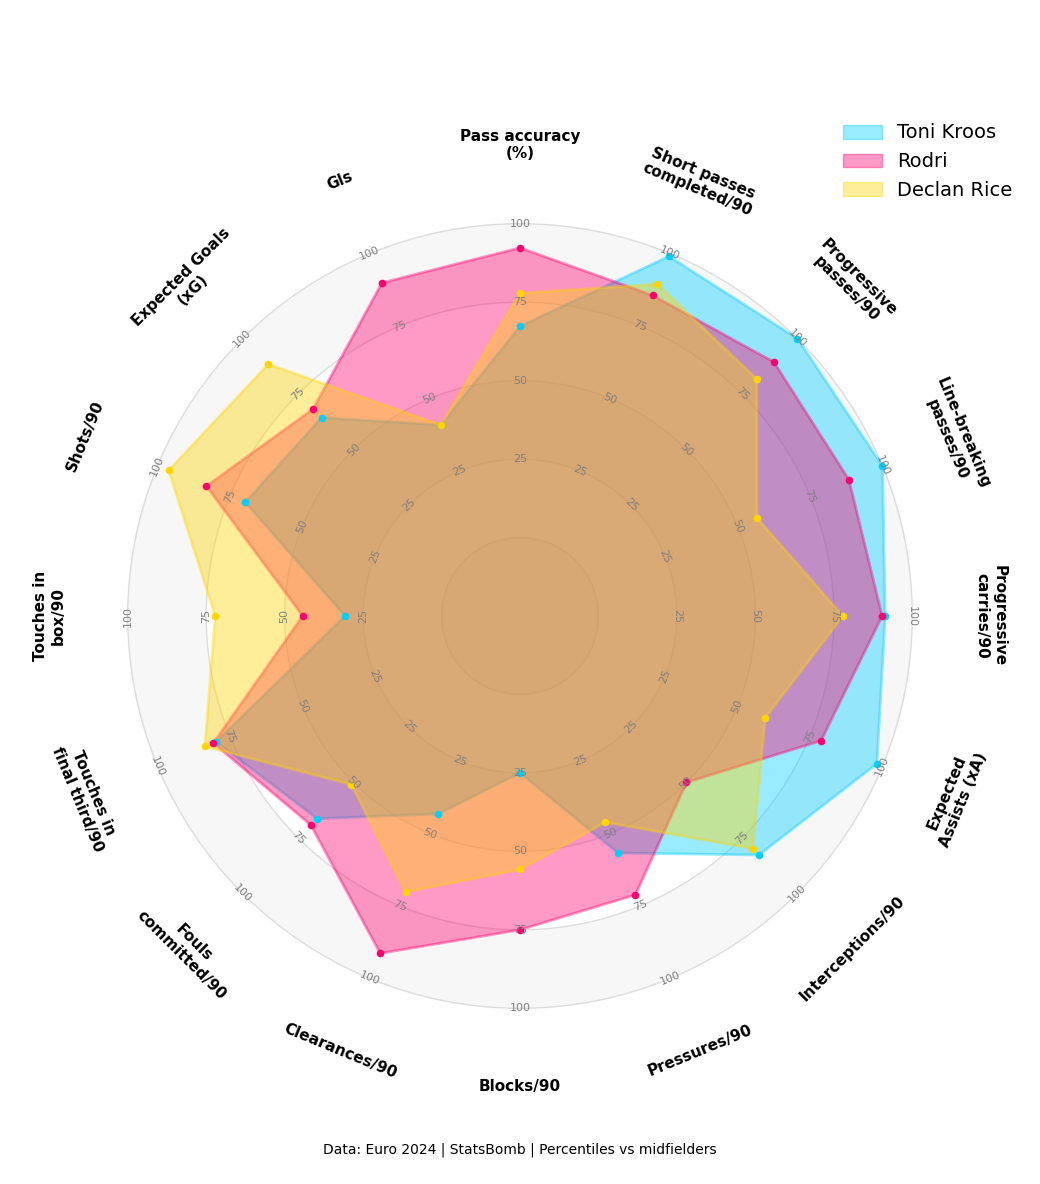

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mplsoccer import Radar, grid
# We include only central and defensive midfielders (all variations in the dataset)
mid_positions = [
    "Center Defensive Midfield",
    "Right Center Midfield",
    "Left Center Midfield",
    "Left Defensive Midfield",
    "Right Defensive Midfield"
]

midfielders = tot[tot["position_name"].isin(mid_positions)].copy()

# --- Metrics ---
params = [
    "Passes_Cmp%",  'Pass_Short_Cmp_90', "Pass_Prog_90", "Pass_LBP_90","Carries_Prog_90", 'xA',
    "Int_90", "Press_90", 'Blocks_90','Clr_90', 'Fouls_Committed_90',
    "Touches_Att3rd_90",'Touches_Box_90', 'Sh','xG', 'Gls'
]
    # --- Build player values in a fixed order: Kroos, Rodri, Rice ---
order = [
    ("Toni Kroos", "Kroos"),
    ("Rodri", "Cascante"),
    ("Declan Rice", "Rice")
]

mid_df = midfielders[["player_name", "team_name", "minutes"] + params].copy()

# Percentiles (0-100) for each metric across all midfielders
percentiles = mid_df.copy()
for m in params:
    percentiles[m] = mid_df[m].rank(pct=True) * 100

# Search by name substring to match players
compare_df = percentiles[
    percentiles["player_name"].str.contains("Kroos|Rice|Cascante", case=False, na=False)
]

compare_df

# --- Rename labels for readability ---
param_labels = {
    "Passes_Cmp%": "Pass accuracy (%)",
    "Pass_Short_Cmp_90": "Short passes completed/90",
    "Pass_Prog_90": "Progressive passes/90",
    "Pass_LBP_90": "Line-breaking passes/90",
    "Carries_Prog_90": "Progressive carries/90",
    "Passes_UnderPress%": "Passes under pressure (%)",
    "xA": "Expected Assists (xA)",
    "Tackles_90": "Tackles/90",
    "Int_90": "Interceptions/90",
    "Press_90": "Pressures/90",
    "Blocks_90": "Blocks/90",
    "Clr_90": "Clearances/90",
    "Fouls_Committed_90": "Fouls committed/90",
    "Touches_Att3rd_90": "Touches in final third/90",
    "Touches_Box_90": "Touches in box/90",
    "Sh": "Shots/90",
    "xG": "Expected Goals (xG)"
}
params_renamed = [param_labels.get(p, p) for p in params]

# --- Radar setup with renamed params ---
low = [0] * len(params_renamed)
high = [100] * len(params_renamed)
radar = Radar(params=params_renamed, min_range=low, max_range=high,
              num_rings=4, round_int=[True]*len(params_renamed))

# colors
style_map = {
    "Toni Kroos": {"facecolor": "#00CFFF", "alpha": 0.40, "edgecolor": "#00CFFF", "lw": 2},  # Cyan / light blue
    "Rodri":      {"facecolor": "#FF006E", "alpha": 0.40, "edgecolor": "#FF006E", "lw": 2},  # Fuchsia / magenta
    "Declan Rice":{"facecolor": "#FFD500", "alpha": 0.40, "edgecolor": "#FFD500", "lw": 2},  # Bright yellow
}

# Build values in fixed order (skip gracefully if someone is missing)
values, labels, styles = [], [], []
for label, key in order:
    rows = compare_df[compare_df["player_name"].str.contains(key, case=False, na=False)]
    if not rows.empty:
        values.append(rows.iloc[0][params].tolist())
        labels.append(label)
        styles.append(style_map[label])

# 7) Plot
fig, axs = grid(figheight=12, grid_height=0.85, title_height=0.08,
                endnote_height=0.04, title_space=0, endnote_space=0,
                grid_key='radar', axis=False)

radar.setup_axis(ax=axs['radar'])
radar.draw_circles(ax=axs['radar'], facecolor="#f7f7f7", edgecolor="#dcdcdc")

for val, style in zip(values, styles):
    radar_poly, verts = radar.draw_radar_solid(val, ax=axs['radar'], kwargs=style)
    axs['radar'].scatter(verts[:, 0], verts[:, 1], c=style["facecolor"],
                         edgecolors=style["edgecolor"], s=20, zorder=2)

# Labels
radar.draw_range_labels(ax=axs['radar'], fontsize=8, color="gray", fontweight="normal")
radar.draw_param_labels(ax=axs['radar'], fontsize=11, fontweight="semibold")

# Title & footnote
axs['title'].text(0.5, 0.7, "", fontsize=18,
                  ha='center', va='center', weight="bold")
axs['endnote'].text(0.5, 0.5, "Data: Euro 2024 | StatsBomb | Percentiles vs midfielders",
                    fontsize=10, ha='center', va='center')

# Legend
legend_handles = [
    Patch(facecolor=style_map[l]["facecolor"], edgecolor=style_map[l]["edgecolor"],
          alpha=style_map[l]["alpha"], label=l)
    for l in labels
]
axs['radar'].legend(handles=legend_handles, loc="upper right",
                    bbox_to_anchor=(1, 1), frameon=False, fontsize=14)

plt.show()

# **PROGRESSIVE PASSES MAP**

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Toni Kroos — Progressive Pass Map (EURO 2024)'}>)

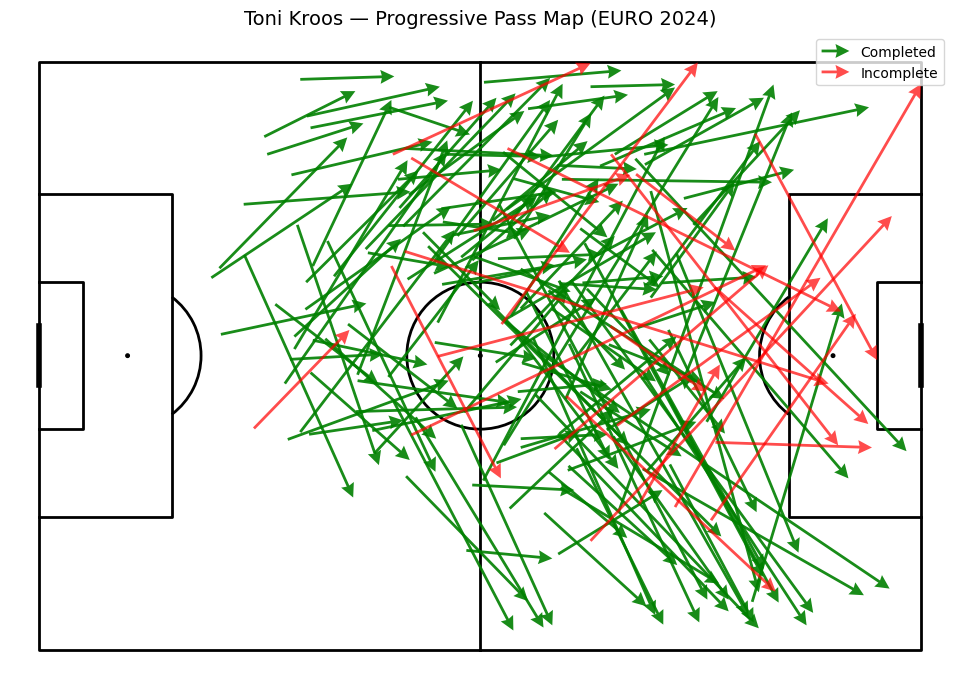

In [ ]:

import matplotlib.pyplot as plt
from mplsoccer import Pitch

# ---------- Progressive-pass selector ----------
def select_progressive_passes(df, player_name=None, match_id=None):
    """
    Select only PASS events that are 'progressive'.
    - Prefer the native boolean flag 'pass_progressive' when available.
    - Fallback heuristic: (end_x - start_x) > 10 meters AND end_x > 40.
    Optional filters:
      - player_name: restrict to a specific player
      - match_id:    restrict to a specific match
    """
    # 1) Keep only passes
    ps = df[df[col_type].eq('Pass')].copy()

    # 2) Optional filters
    if player_name:
        ps = ps[ps[col_pname] == player_name]
    if match_id is not None:
        ps = ps[ps['match_id'] == match_id]

    # 3) Progressive flag
    if 'pass_progressive' in ps.columns:
        ps = ps[ps['pass_progressive'] == True].copy()
    else:
        # Heuristic using start/end x positions
        def is_prog(row):
            try:
                sx = float(row[col_loc][0]); ex = float(row[col_pass_end][0])
                return (ex - sx) > 10 and ex > 40
            except Exception:
                return False
        ps = ps.dropna(subset=[col_loc, col_pass_end]).copy()
        ps['is_prog'] = ps.apply(is_prog, axis=1)
        ps = ps[ps['is_prog']].copy()

    return ps

# ---------- Plot function ----------
def plot_progressive_pass_map(df_prog, title="Progressive Pass Map", show_completion=True):
    """
    Plot progressive passes on a StatsBomb pitch using mplsoccer.
    - df_prog: DataFrame with columns 'location' and 'pass_end_location'
    - show_completion: color by completion (green completed, red incomplete)
    """
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    fig, ax = pitch.draw(figsize=(10, 7))
    ax.set_title(title, fontsize=14)

    # Split by completion (StatsBomb open data: pass outcome NaN ≈ completed)
    if show_completion and col_pass_out in df_prog.columns:
        comp = df_prog[df_prog[col_pass_out].isna()]
        fail = df_prog[df_prog[col_pass_out].notna()]
        # Completed = green arrows
        if not comp.empty:
            pitch.arrows(
                comp[col_loc].str[0], comp[col_loc].str[1],
                comp[col_pass_end].str[0], comp[col_pass_end].str[1],
                ax=ax, width=2, headwidth=5, color='green', alpha=0.9, label='Completed'
            )
        # Incomplete = red arrows
        if not fail.empty:
            pitch.arrows(
                fail[col_loc].str[0], fail[col_loc].str[1],
                fail[col_pass_end].str[0], fail[col_pass_end].str[1],
                ax=ax, width=2, headwidth=5, color='red', alpha=0.7, label='Incomplete'
            )
        ax.legend(loc='upper right')
    else:
        # All in a single color if completion not desired/available
        pitch.arrows(
            df_prog[col_loc].str[0], df_prog[col_loc].str[1],
            df_prog[col_pass_end].str[0], df_prog[col_pass_end].str[1],
            ax=ax, width=2, headwidth=5, color='blue', alpha=0.85
        )
    return fig, ax

# ---------- Example: Toni Kroos (whole tournament) ----------
kroos_prog = select_progressive_passes(events, player_name='Toni Kroos', match_id=None)
plot_progressive_pass_map(kroos_prog, title="Toni Kroos — Progressive Pass Map (EURO 2024)")


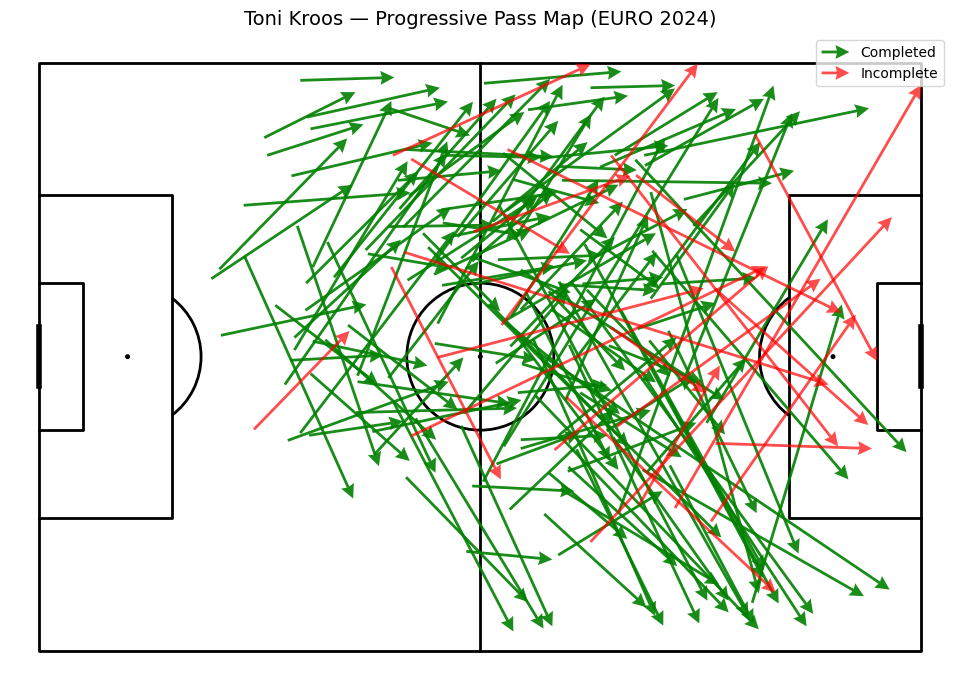

In [ ]:
# Create the graphic
fig, ax = plot_progressive_pass_map(kroos_prog, title="Toni Kroos — Progressive Pass Map (EURO 2024)")

# Save png no background
fig.savefig("kroos_prog_passes.png", dpi=300, bbox_inches="tight", transparent=True)


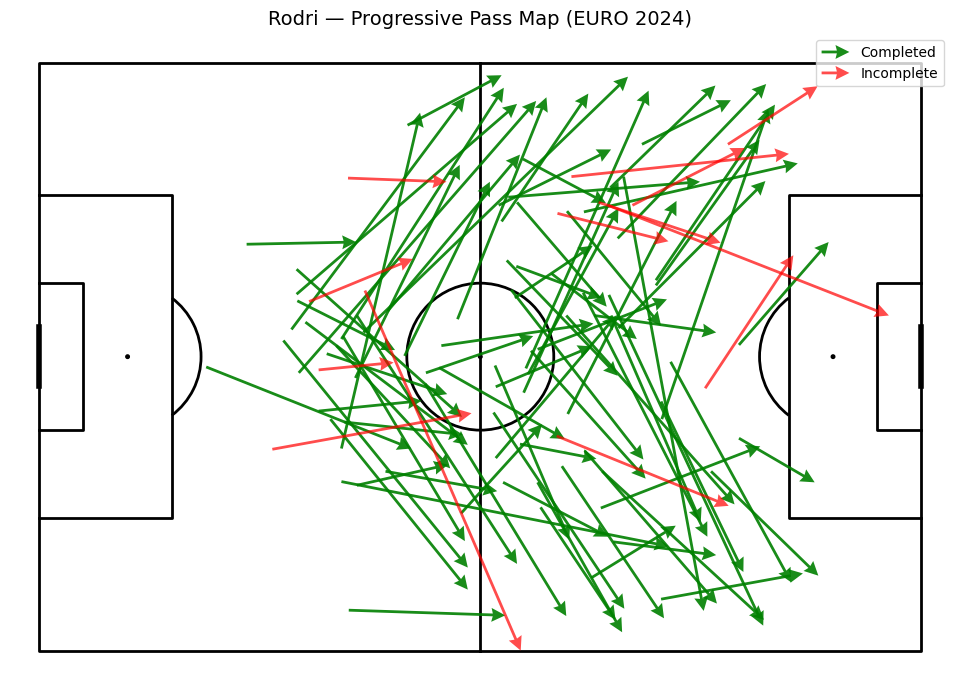

In [ ]:
# ---------- Example: Rodri ----------
rodri_prog = select_progressive_passes(events, player_name='Rodrigo Hernández Cascante', match_id=None)
fig, ax=plot_progressive_pass_map(rodri_prog, title="Rodri — Progressive Pass Map (EURO 2024)")

# save png no background
fig.savefig("rodri_prog_passes.png", dpi=300, bbox_inches="tight", transparent=True)

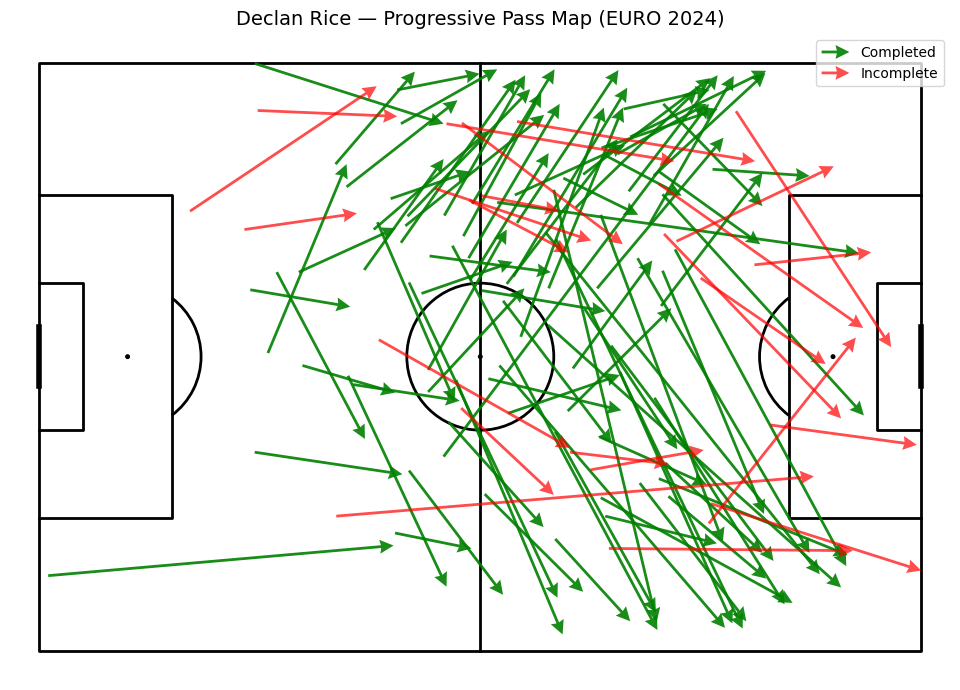

In [ ]:
# ---------- Example: Declan Rice ----------
rice_prog = select_progressive_passes(events, player_name='Declan Rice', match_id=None)
fig, ax=plot_progressive_pass_map(rice_prog, title="Declan Rice — Progressive Pass Map (EURO 2024)")
fig.savefig("Rice_prog_passes.png", dpi=300, bbox_inches="tight", transparent=True)


# **LINE-BREAKING PASSES MAP**



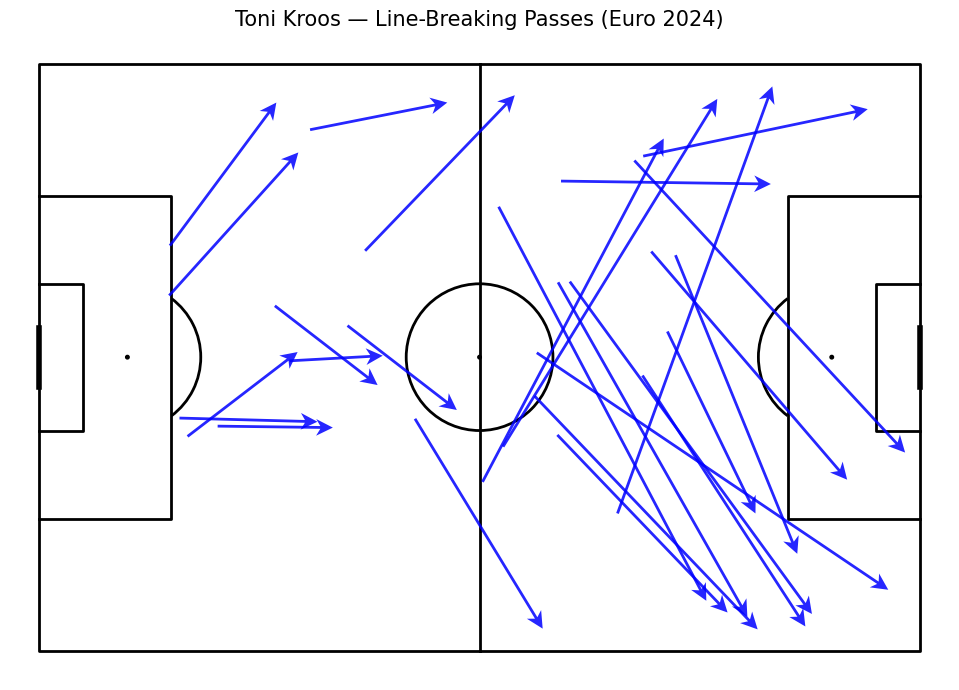

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1) Precompute a single defensive barrier per event from 360 frames (max opponent x)

if 'bars' not in globals():
    opp = frames360[(frames360['teammate'] == False) & frames360['location'].notna()].copy()
    bars = (
        opp.assign(x=opp['location'].str[0].astype(float))   # vectorized start-x
           .groupby('id')['x'].max()
           .rename('bar_x')
           .reset_index()
           .rename(columns={'id': 'event_id'})
    )

# 2) Helper to plot LBP for a given player (completed passes only)
def plot_lbp_player(player_name, title=None):
    ps = events[(events['type'] == 'Pass') & (events['player'] == player_name)].copy()
    if 'pass_outcome' in ps.columns:
        ps = ps[ps['pass_outcome'].isna()]  # completed passes only

    ps = ps.dropna(subset=['location', 'pass_end_location'])
    ps = ps.merge(bars, left_on='id', right_on='event_id', how='left')

    # Vectorized start/end x
    ps['sx'] = ps['location'].str[0].astype(float)
    ps['ex'] = ps['pass_end_location'].str[0].astype(float)

    # LBP: start_x <= bar_x < end_x AND forward movement > 2m
    lbp = ps[(ps['bar_x'].notna()) &
             ((ps['ex'] - ps['sx']) > 2.0) &
             (ps['sx'] <= ps['bar_x']) &
             (ps['ex'] > ps['bar_x'])]

    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    fig, ax = pitch.draw(figsize=(10, 7))
    ax.set_title(title or f"{player_name} — Line-Breaking Passes (Euro 2024)", fontsize=15)

    if lbp.empty:
        ax.text(60, 40, "No line-breaking passes (or no 360 for those events).",
                ha='center', va='center', fontsize=12)
    else:
        starts = np.vstack(lbp['location'].values)
        ends   = np.vstack(lbp['pass_end_location'].values)
        pitch.arrows(starts[:, 0], starts[:, 1],
                     ends[:, 0],   ends[:, 1],
                     width=2, headwidth=6, headlength=6, color='blue', alpha=0.85, ax=ax)

    return fig, ax

# Example: Toni Kroos
fig, ax = plot_lbp_player('Toni Kroos')
# plt.show()
fig.savefig("Kroos_LBP.png", dpi=300, bbox_inches="tight", transparent=True)


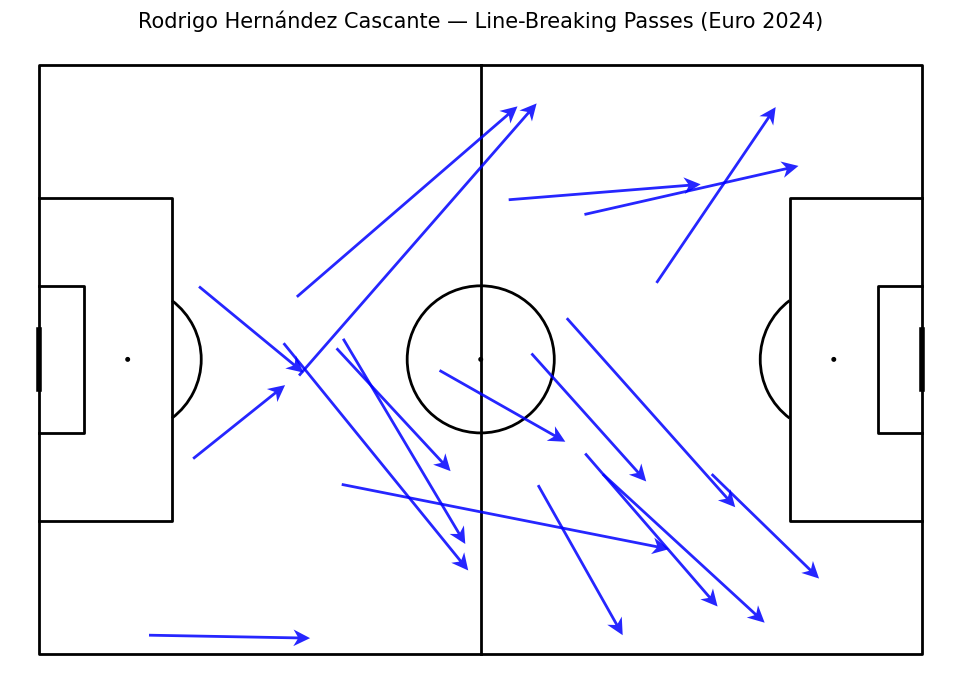

In [ ]:
# Example: plot for Rodri
fig, ax = plot_lbp_player('Rodrigo Hernández Cascante')
plt.show()
fig.savefig("Rodri_LBP.png", dpi=300, bbox_inches="tight", transparent=True)


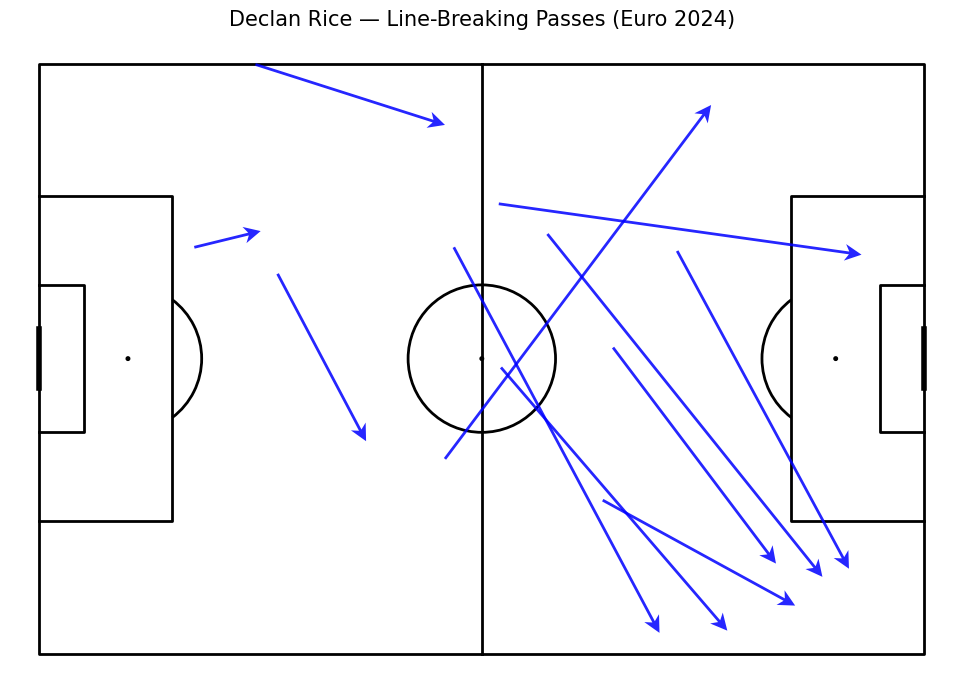

In [ ]:
# Example: plot for Rice
fig, ax = plot_lbp_player('Declan Rice')
plt.show()
fig.savefig("Rice_LBP.png", dpi=300, bbox_inches="tight", transparent=True)

# **SHOT MAP (SIZE: xG)**


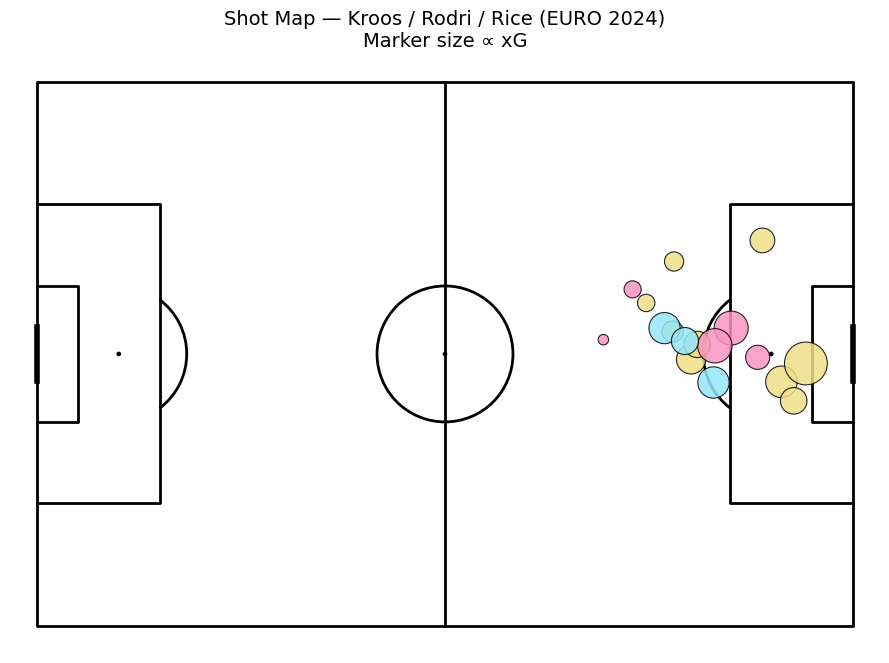

In [ ]:

col_xg = pick_col(events, 'shot_statsbomb_xg', 'shot.statsbomb_xg')
assert col_xg and col_loc and col_type and col_pname, "Missing essential shot columns."

# --- players and colors ---
players = ['Toni Kroos', 'Rodrigo Hernández Cascante', 'Declan Rice']
colors  = {
    'Toni Kroos': '#94e7fa',
    'Rodrigo Hernández Cascante': '#fa94c0',
    'Declan Rice': '#efde88'
}

# --- gather shots once (xG drives marker size) ---
shots_all = (
    events[(events[col_type] == 'Shot') & (events[col_pname].isin(players))]
    .dropna(subset=[col_loc, col_xg])
    .copy()
)

# --- plot on a single StatsBomb pitch ---
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(9, 7))
ax.set_title("Shot Map — Kroos / Rodri / Rice (EURO 2024)\nMarker size ∝ xG", fontsize=14)

SIZE_K = 9000  # keep your visual scale; tweak if needed

# plot each player's shots with their color
for name, sp in shots_all.groupby(col_pname):
    s = (SIZE_K * sp[col_xg].astype(float).clip(lower=0)).values
    ax.scatter(
        sp[col_loc].str[0].astype(float), sp[col_loc].str[1].astype(float),
        s=s, c=colors.get(name, '#888888'),
        alpha=0.85, edgecolors='black', linewidths=0.8, label=name, zorder=3
    )


In [ ]:
fig.savefig("shots_kroos_rodri_rice.png", dpi=300, bbox_inches="tight", transparent=True)


# **Defensive Actions Heatmaps**


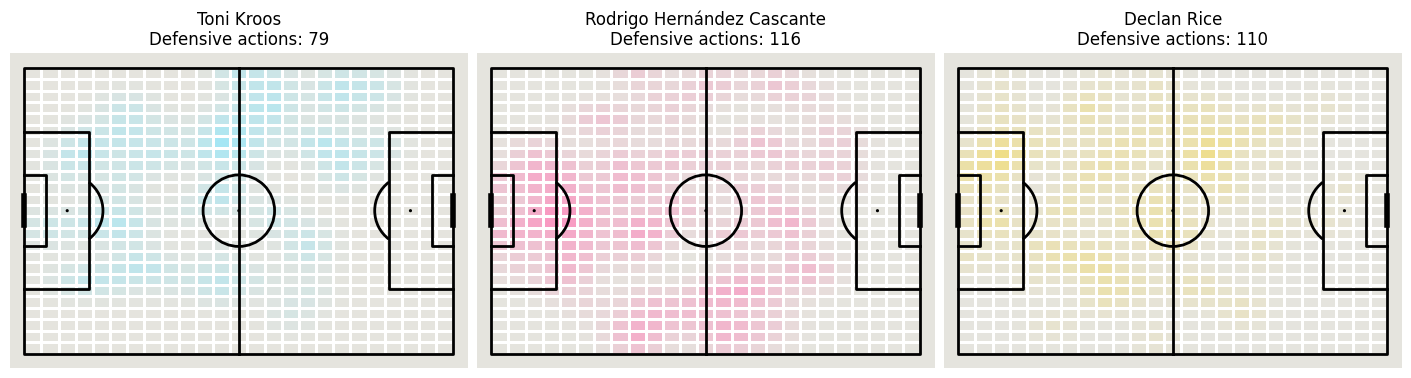

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from mplsoccer import Pitch

# --- configuration ---
players = ['Toni Kroos', 'Rodrigo Hernández Cascante', 'Declan Rice']
player_colors = {
    'Toni Kroos': '#94e7fa',
    'Rodrigo Hernández Cascante': '#fa94c0',
    'Declan Rice': '#efde88'
}
def_types = {'Pressure', 'Tackle', 'Interception', 'Block', 'Clearance'}
bins = (25, 25)
sigma = 1

# --- build pitch ---
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='#e5e4de', line_color='black')

# --- collect & bin per player (one pass) ---
per_player = {}
for p in players:
    sub = events[
        (events['player'] == p) &
        (events['type'].isin(def_types)) &
        (events['location'].notna())
    ]
    if sub.empty:
        per_player[p] = {'stat': None, 'count': 0}
        continue
    xs = sub['location'].str[0].astype(float).to_numpy()
    ys = sub['location'].str[1].astype(float).to_numpy()
    stat = pitch.bin_statistic(xs, ys, statistic='count', bins=bins)
    stat['statistic'] = gaussian_filter(stat['statistic'], sigma=sigma)
    per_player[p] = {'stat': stat, 'count': len(sub)}

# --- global normalization across players ---
vmax_common = max(
    (np.nanmax(v['stat']['statistic']) for v in per_player.values() if v['stat'] is not None),
    default=1.0
)

# --- prebuild colormaps per player (white -> player color) ---
cmaps = {
    p: LinearSegmentedColormap.from_list(f"cmap_{p}", ["#e5e4de", player_colors[p]])
    for p in players
}

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
fig.set_facecolor('white')

for ax, p in zip(axes, players):
    pitch.draw(ax=ax)
    st = per_player[p]['stat']
    if st is None:
        ax.set_title(f"{p}\nNo defensive actions", fontsize=12, color='black')
        continue
    pitch.heatmap(st, ax=ax, cmap=cmaps[p], vmin=0, vmax=vmax_common, edgecolors='white')
    ax.set_title(f"{p}\nDefensive actions: {per_player[p]['count']}", fontsize=12, color='black')

plt.savefig("defensive_heatmaps.png", dpi=300, bbox_inches='tight', transparent=False)

